
Largest Residual:
X = 0.73, Y = -0.8754, Residual = -1.0152

Smallest residual:
X = 0.01, Y = -1.1534, Residual = -0.0049

Chosen Slope: 1.6709857118202116, Chosen Intercept: -1.118758483796948
Estimated Slope (My Custom LS): 1.7892466420972184, Estimated Intercept (My Custom LS): -1.166364535470926
Estimated Slope (NumPy LS): 1.7892466420972184, Estimated Intercept (NumPy LS): -1.1663645354709262


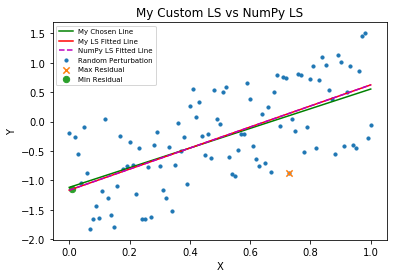

In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Define my own Least Squares function
def my_least_squares(X, Y):
    A = np.vstack([X, np.ones(len(X))]).T
    theta = np.linalg.inv(A.T @ A) @ (A.T @ Y)
    m, c = theta[0], theta[1]
    return m, c


X = np.arange(0, 1.01, 0.01) # Compute X from 0 to 1 with steps of 0.01
X = np.sort(X)  # sort the X vector



# Random linear equation with random error. Used chatGPT to understand difference between this and choosing a fixed linear line with random noise
my_m = np.random.uniform(-5, 5)
my_c = np.random.uniform(-5, 5)

# Random error implementation
perturbation = np.random.uniform(0, 1, len(X))
sign = np.random.choice([-1, 1], len(X))
Y = my_m*X + my_c + sign * perturbation


# Using my custom Least Squares to calculate m and c
m, c = my_least_squares(X, Y)


# Using numpy Least Squares to compare
A = np.vstack([X, np.ones(len(X))]).T
m_numpy, c_numpy = np.linalg.lstsq(A, Y, rcond=None)[0]


# Compute residual = actual value - predicted value
Ypredictions = m*X + c
residuals = Y - Ypredictions

# Max and Min residuals
max_residual_index = np.argmax(np.abs(residuals))
min_residual_index = np.argmin(np.abs(residuals))



print("\nLargest Residual:")
print(f"X = {X[max_residual_index]:.2f}, Y = {Y[max_residual_index]:.4f}, Residual = {residuals[max_residual_index]:.4f}")

print("\nSmallest residual:")
print(f"X = {X[min_residual_index]:.2f}, Y = {Y[min_residual_index]:.4f}, Residual = {residuals[min_residual_index]:.4f}")



# Print chosen and estimated slopes/intercepts
print(f"\nChosen Slope: {my_m}, Chosen Intercept: {my_c}")
print(f"Estimated Slope (My Custom LS): {m}, Estimated Intercept (My Custom LS): {c}")
print(f"Estimated Slope (NumPy LS): {m_numpy}, Estimated Intercept (NumPy LS): {c_numpy}")


# Plotting
plt.scatter(X, Y, s=10, label='Random Perturbation')
plt.plot(X, my_m*X + my_c, 'g', label='My Chosen Line')
plt.plot(X, m*X + c, 'r', label='My LS Fitted Line')
plt.plot(X, m_numpy*X + c_numpy, 'm--', label='NumPy LS Fitted Line')
plt.scatter(X[max_residual_index], Y[max_residual_index], s=40, marker='x', label='Max Residual')
plt.scatter(X[min_residual_index], Y[min_residual_index], s=40, marker='o', label='Min Residual')
plt.title('My Custom LS vs NumPy LS')
plt.legend(fontsize=7)
plt.xlabel('X')
plt.ylabel('Y')
plt.show()